# Visualisasi Interpretasi SHAP

Visualisasi Random Forest dari **hasil SHAP penelitian tersimpan**, tanpa melatih
model atau menghitung ulang SHAP. M4 menggunakan lag LST, NDVI, dan NDBI dengan
model terpisah per klaster. Data ini bukan SHAP ulang dari artefak Forecasting.

Urutan visualisasi mengikuti dashboard:
1. Porsi kontribusi tiap variabel per model.
2. Besar kontribusi dalam satuan suhu.
3. Ringkasan SHAP: rata-rata, simpangan baku, dan proporsi.
4. Porsi kontribusi tiap variabel per klaster M4–RF.
5. Hasil SHAP masing-masing klaster M4–RF.

Jalankan **Run All** dari direktori proyek atau folder `sintaks`.
Dependensi: `pandas`, `numpy`, `matplotlib`, dan `ipython`.
Grafik ditampilkan di notebook dan disimpan sebagai PNG 180 dpi serta PDF
di `sintaks/output_interpretasi_shap/`.

Nilai absolut SHAP menunjukkan **besar kontribusi**, bukan arah pemanasan atau
pendinginan dan bukan bukti sebab-akibat. Simpangan baku menunjukkan sebaran
nilai, bukan interval kepercayaan. Persentase dapat sedikit berbeda dari 100%
karena pembulatan.


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Temukan proyek tanpa mengunci jalur ke komputer tertentu.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'data/tabel_vector_shap_summary.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Jalankan notebook dari folder uhi-dashboard atau sintaks.')
DATA = ROOT / 'data'
OUTPUT = ROOT / 'sintaks/output_interpretasi_shap'
OUTPUT.mkdir(parents=True, exist_ok=True)

VARIABLES = ['LST', 'NDVI', 'NDBI']
MODELS = ['M1', 'M2', 'M3', 'M4']
VARIABLE_COLORS = {'LST': '#d73027', 'NDVI': '#1baf7a', 'NDBI': '#eb6834'}
CLUSTER_COLORS = {1: '#9EAFE5', 2: '#8FD0B5', 3: '#F7ABAD', 4: '#D0AFE0'}
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})

def save_show(fig, name):
    for extension in ['png', 'pdf']:
        fig.savefig(OUTPUT / f'{name}.{extension}', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Data:', DATA)
print('Ekspor:', OUTPUT)


Data: c:\Users\Solideo G. Bangun\uhi-dashboard\data
Ekspor: c:\Users\Solideo G. Bangun\uhi-dashboard\sintaks\output_interpretasi_shap


## Sumber data

- `data/tabel_vector_shap_summary.csv`: agregasi absolut SHAP seluruh lag per variabel untuk M1–M4.
- `data/true_vector_shap_cluster_M4_LagAll_byCluster.csv`: agregasi per variabel dan klaster pada M4–RF.

Jumlah sampel pada file klaster adalah grid yang dipakai untuk ringkasan SHAP,
bukan seluruh anggota klaster. Nilai SHAP disajikan dalam °C.


In [12]:
summary = pd.read_csv(DATA / 'tabel_vector_shap_summary.csv').rename(columns={
    'Model': 'model', 'Variabel': 'variable', 'Vector SHAP (mean)': 'mean',
    'Vector SHAP (std)': 'std', 'Kontribusi (%)': 'percentage',
    'Jumlah Lag': 'n_lags', 'Lag Terkuat': 'strongest_lag',
    'SHAP Lag Terkuat': 'strongest_lag_shap'})
summary['code'] = summary['model'].str.split(':').str[0].str.strip()
clusters = pd.read_csv(DATA / 'true_vector_shap_cluster_M4_LagAll_byCluster.csv').rename(columns={
    'vector_shap_mean': 'mean', 'vector_shap_std': 'std',
    'vector_shap_pct': 'percentage', 'vector_shap_median': 'median',
    'vector_shap_q25': 'q25', 'vector_shap_q75': 'q75'})
assert not summary.duplicated(['code', 'variable']).any()
assert not clusters.duplicated(['cluster', 'variable']).any()
assert set(summary['code']) == set(MODELS)
assert set(clusters['cluster']) == {1, 2, 3, 4}
for frame, group in [(summary, 'code'), (clusters, 'cluster')]:
    assert np.isfinite(frame[['mean', 'std', 'percentage']].to_numpy()).all()
    assert (frame[['mean', 'std', 'percentage']] >= 0).all().all()
    np.testing.assert_allclose(frame.groupby(group)['percentage'].sum(), 100, atol=0.05)
display(summary)
display(clusters)


,model,variable,n_lags,mean,std,percentage,strongest_lag,strongest_lag_shap,code
0,M1: Lag LST saja,LST,5,1.09034,0.60728,100.00,2012,0.40198,M1
1,M2: Lag LST (per Cluster),LST,5,0.97972,0.55109,100.00,2012,0.33107,M2
2,M3: Lag LST + NDVI + NDBI,LST,5,0.73709,0.53368,59.68,2012,0.29087,M3
3,M3: Lag LST + NDVI + NDBI,NDBI,6,0.28344,0.10851,22.95,2021,0.07407,M3
4,M3: Lag LST + NDVI + NDBI,NDVI,6,0.21460,0.07762,17.37,2012,0.07031,M3
5,M4: Lag LST + NDVI + NDBI (per Cluster),LST,5,0.64716,0.46454,57.34,2012,0.21527,M4
6,M4: Lag LST + NDVI + NDBI (per Cluster),NDBI,6,0.28916,0.13879,25.62,2021,0.06751,M4
7,M4: Lag LST + NDVI + NDBI (per Cluster),NDVI,6,0.19223,0.08218,17.03,2012,0.04904,M4


,cluster,variable,mean,std,vector_shap_sem,q25,q75,median,percentage,n_samples
0,1,LST,0.621241,0.635322,0.124597,0.231395,0.677246,0.377789,63.45,26
1,1,NDVI,0.216613,0.141636,0.027777,0.095642,0.304624,0.220048,22.12,26
2,1,NDBI,0.141210,0.126372,0.024784,0.067141,0.161335,0.099487,14.42,26
3,2,LST,0.336409,0.253313,0.047872,0.157356,0.437054,0.229125,45.12,28
4,2,NDBI,0.276182,0.156169,0.029513,0.160646,0.419656,0.259210,37.04,28
5,2,NDVI,0.133013,0.156900,0.029651,0.018254,0.174361,0.041160,17.84,28
6,3,LST,0.602555,0.738031,0.116693,0.115465,0.755525,0.346300,63.11,40
7,3,NDBI,0.281101,0.156002,0.024666,0.161945,0.371191,0.287138,29.44,40
8,3,NDVI,0.071139,0.069755,0.011029,0.016687,0.092621,0.046888,7.45,40
9,4,LST,0.554818,0.425135,0.072910,0.239298,0.744907,0.464427,62.97,34


## 1. Porsi kontribusi tiap variabel per model

M1/M2 hanya memakai LST; M3/M4 menambahkan NDVI dan NDBI. Warna menunjukkan variabel.

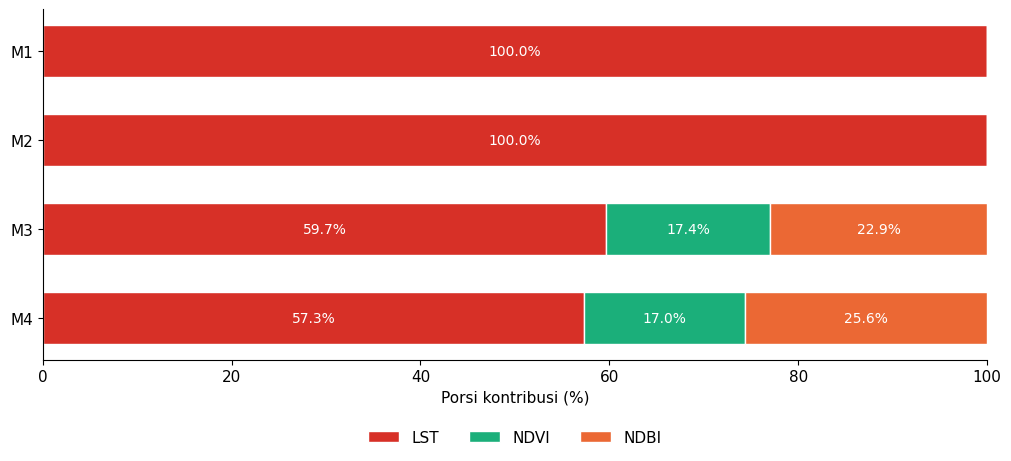

In [13]:
def composition(frame, group, order, labels, title, filename):
    values = frame.pivot(index=group, columns='variable', values='percentage')
    values = values.reindex(index=order, columns=VARIABLES).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
    positions = np.arange(len(order))
    left = np.zeros(len(order))
    for variable in VARIABLES:
        portions = values[variable].to_numpy()
        ax.barh(positions, portions, left=left, height=.58,
                color=VARIABLE_COLORS[variable], label=variable, edgecolor='white')
        for i, value in enumerate(portions):
            if value >= 5:
                ax.text(left[i] + value / 2, i, f'{value:.1f}%',
                        ha='center', va='center', color='white', fontsize=10)
        left += portions
    ax.set(yticks=positions, yticklabels=labels, xlim=(0, 100),
           xlabel='Porsi kontribusi (%)', title=title)
    ax.invert_yaxis()
    ax.legend(loc='upper center', bbox_to_anchor=(.5, -.16), ncol=3, frameon=False)
    save_show(fig, filename)

composition(summary, 'code', MODELS, MODELS,
            '', '01_kontribusi_per_model')


## 2. Besar kontribusi dalam satuan suhu

Rata-rata jumlah |SHAP| per variabel. Variabel yang tidak digunakan oleh M1/M2 tidak diberi batang.

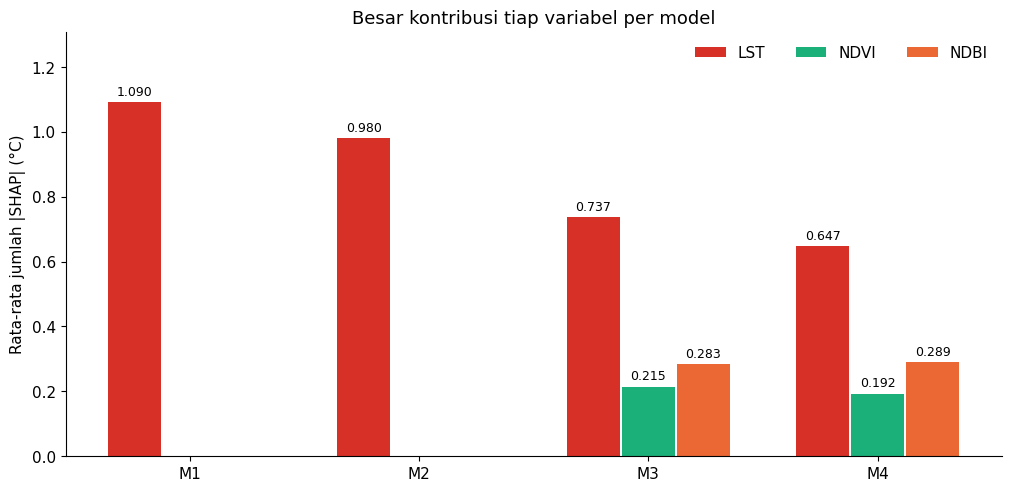

In [14]:
means = summary.pivot(index='code', columns='variable', values='mean').reindex(index=MODELS, columns=VARIABLES)
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
x = np.arange(len(MODELS))
for i, variable in enumerate(VARIABLES):
    bars = ax.bar(x + (i - 1) * .24, means[variable], .23,
                  label=variable, color=VARIABLE_COLORS[variable])
    ax.bar_label(bars, labels=[f'{v:.3f}' if pd.notna(v) else '' for v in means[variable]], padding=3, fontsize=9)
ax.set(xticks=x, xticklabels=MODELS, ylabel='Rata-rata jumlah |SHAP| (°C)',
       title='Besar kontribusi tiap variabel per model')
ax.set_ylim(0, float(means.max().max()) * 1.2)
ax.legend(frameon=False, ncol=3)
save_show(fig, '02_besar_kontribusi_suhu')


## 3. Ringkasan SHAP: rata-rata, simpangan baku, dan proporsi

Ubah `SELECTED_MODEL` ke M1, M2, M3, atau M4. Garis galat menunjukkan ± satu simpangan baku, bukan arah kontribusi.

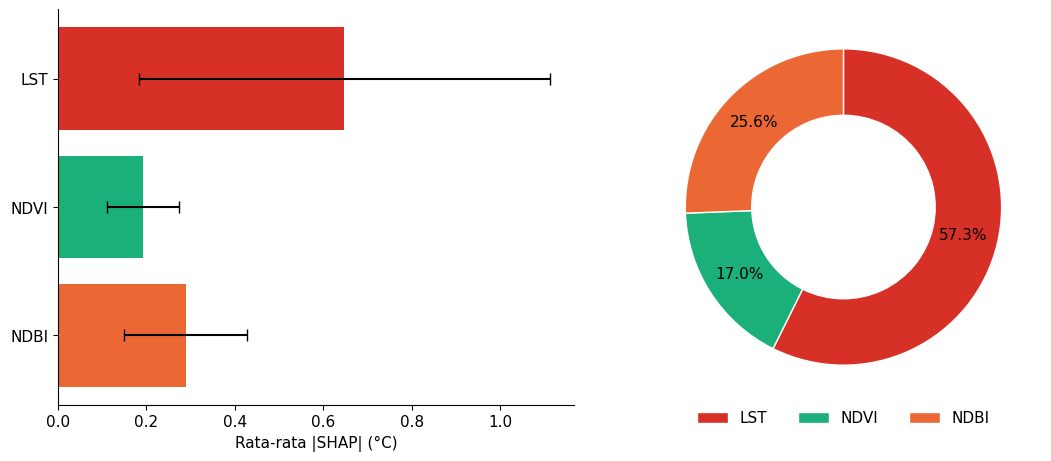

,mean,std,percentage
variable,,,
LST,0.64716,0.46454,57.34
NDVI,0.19223,0.08218,17.03
NDBI,0.28916,0.13879,25.62


In [15]:
SELECTED_MODEL = 'M4'
if SELECTED_MODEL not in MODELS:
    raise ValueError('Pilih M1, M2, M3, atau M4.')
selected = summary[summary['code'].eq(SELECTED_MODEL)].set_index('variable')
selected = selected.reindex([v for v in VARIABLES if v in selected.index])
colors = [VARIABLE_COLORS[v] for v in selected.index]
fig, (ax, pie) = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
ax.barh(selected.index, selected['mean'], xerr=selected['std'], capsize=4, color=colors)
ax.invert_yaxis()
ax.set(title=f'', xlabel='Rata-rata |SHAP| (°C)')
wedges, _, _ = pie.pie(selected['percentage'], colors=colors, startangle=90,
                       counterclock=False, autopct='%1.1f%%', pctdistance=.78,
                       wedgeprops={'width': .42, 'edgecolor': 'white'})
pie.set_title(f'')
pie.legend(wedges, selected.index, loc='upper center', bbox_to_anchor=(.5, .02),
           ncol=len(selected), frameon=False)
save_show(fig, f'03_ringkasan_{SELECTED_MODEL}_RF')
display(selected[['mean', 'std', 'percentage']])


## 4. Porsi kontribusi tiap variabel per klaster

Perbandingan Klaster 1–4 untuk **M4–RF**. Warna segmen tetap menunjukkan variabel.

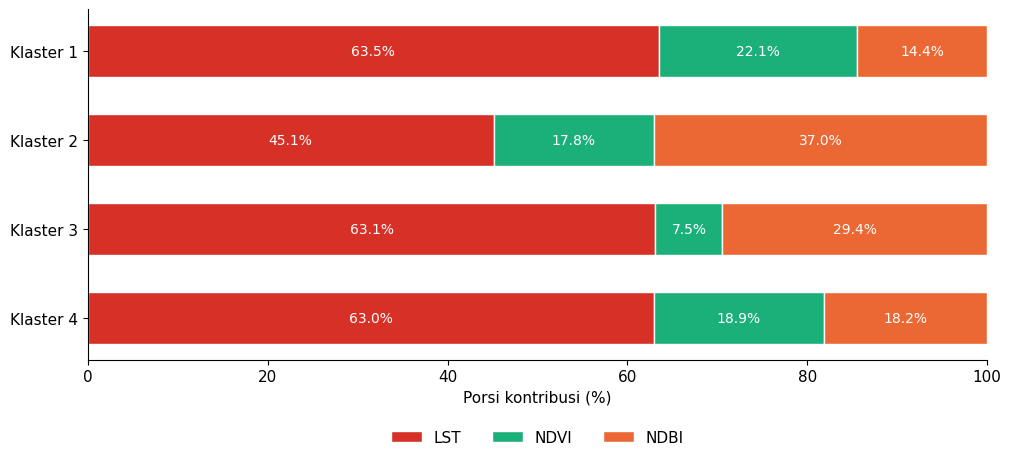

In [16]:
composition(clusters, 'cluster', [1, 2, 3, 4], [f'Klaster {k}' for k in range(1, 5)],
            '', '04_kontribusi_per_klaster_M4_RF')


## 5. Hasil SHAP masing-masing klaster — M4–RF

Warna panel mengikuti palet klaster pada dashboard: biru, hijau, merah muda, ungu. Skala sumbu sama agar besar kontribusi dapat dibandingkan.

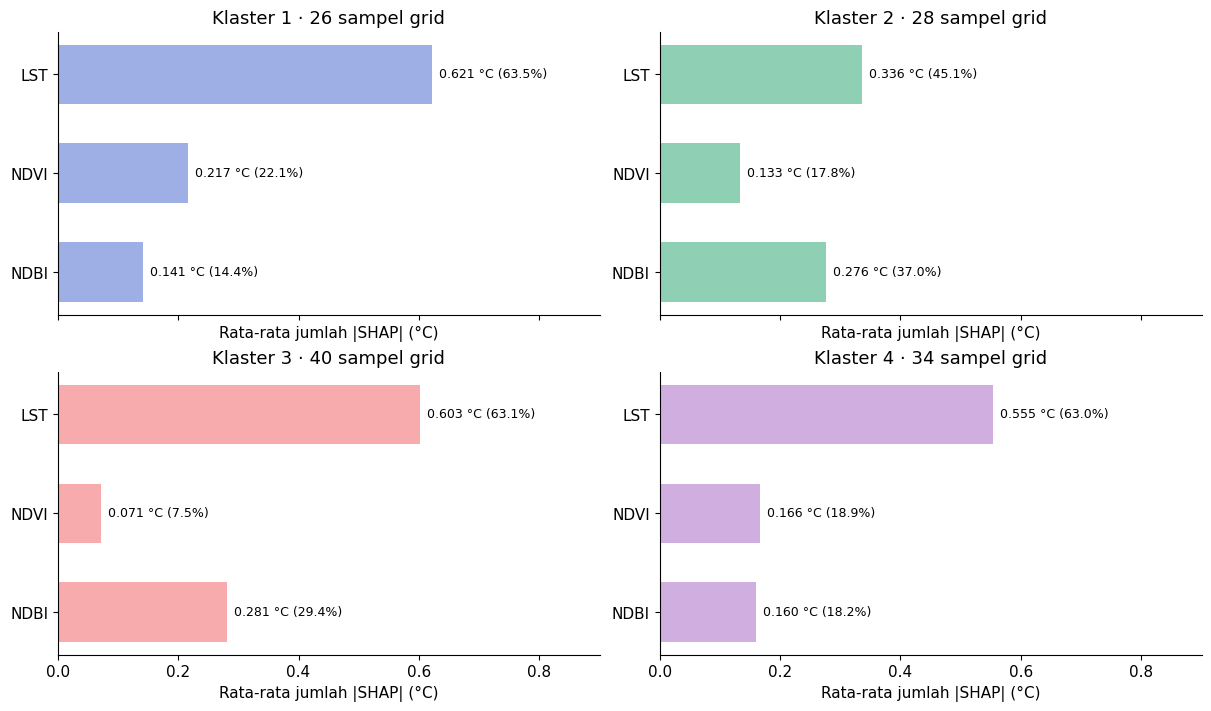

,cluster,variable,mean,std,median,q25,q75,percentage,n_samples
0,1,LST,0.621241,0.635322,0.377789,0.231395,0.677246,63.45,26
1,1,NDVI,0.216613,0.141636,0.220048,0.095642,0.304624,22.12,26
2,1,NDBI,0.141210,0.126372,0.099487,0.067141,0.161335,14.42,26
3,2,LST,0.336409,0.253313,0.229125,0.157356,0.437054,45.12,28
4,2,NDBI,0.276182,0.156169,0.259210,0.160646,0.419656,37.04,28
5,2,NDVI,0.133013,0.156900,0.041160,0.018254,0.174361,17.84,28
6,3,LST,0.602555,0.738031,0.346300,0.115465,0.755525,63.11,40
7,3,NDBI,0.281101,0.156002,0.287138,0.161945,0.371191,29.44,40
8,3,NDVI,0.071139,0.069755,0.046888,0.016687,0.092621,7.45,40
9,4,LST,0.554818,0.425135,0.464427,0.239298,0.744907,62.97,34


Selesai. Semua grafik dan tabel tersedia di: c:\Users\Solideo G. Bangun\uhi-dashboard\sintaks\output_interpretasi_shap


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, layout='constrained')
limit = float(clusters['mean'].max()) * 1.45
for k, ax in zip(range(1, 5), axes.flat):
    rows = clusters[clusters['cluster'].eq(k)].set_index('variable').reindex(VARIABLES)
    bars = ax.barh(VARIABLES, rows['mean'], color=CLUSTER_COLORS[k], height=.6)
    ax.bar_label(bars, labels=[f'{r["mean"]:.3f} °C ({r["percentage"]:.1f}%)'
                              for _, r in rows.iterrows()], padding=5, fontsize=9)
    ax.invert_yaxis()
    ax.set(xlim=(0, limit), xlabel='Rata-rata jumlah |SHAP| (°C)',
           title=f'Klaster {k} · {int(rows["n_samples"].iloc[0])} sampel grid')
save_show(fig, '05_shap_masing_masing_klaster_M4_RF')
table = clusters[['cluster', 'variable', 'mean', 'std', 'median', 'q25', 'q75', 'percentage', 'n_samples']]
display(table)
table.to_csv(OUTPUT / 'shap_per_klaster_M4_RF.csv', index=False, encoding='utf-8-sig')
summary.to_csv(OUTPUT / 'shap_per_model_RF.csv', index=False, encoding='utf-8-sig')
print('Selesai. Semua grafik dan tabel tersedia di:', OUTPUT)
